<a href="https://colab.research.google.com/github/lisadbaer/lab-2-predictive-analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Lisa
**Student ID:** Baer

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

taxi shape. 
Rows: 
41202  columns: 
13

taxi head: 
   VendorID  passenger_count  trip_distance  RatecodeID  store_and_fwd_flag  \
0         2                1          17.63           2                   1   
1         2                1          19.52           2                   1   
2         2                1          17.81           2                   1   
3         2                2          19.30           2                   1   
4         2                1          18.75           2                   1   

   PULocationID  DOLocationID  payment_type  fare_amount  mta_tax  \
0           132           164             1         70.0      0.5   
1           132           236             1         70.0      0.5   
2           132            48             1         70.0      0.5   
3           132           148             1         70.0      0.5   
4           132           234             1         70.0      0.5   

   tolls_amount  improvement_surcharge  tip_amount  
0   

(0.0, 300.0)

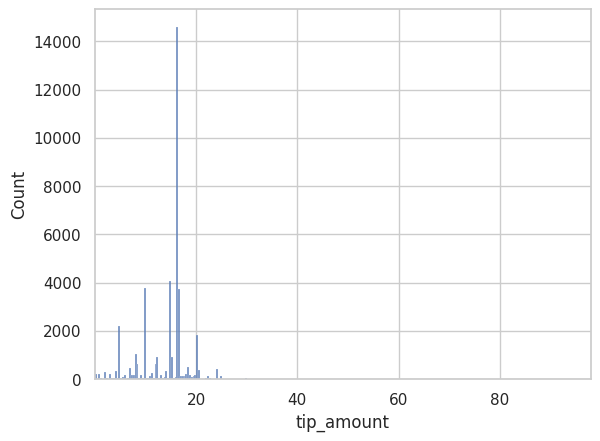

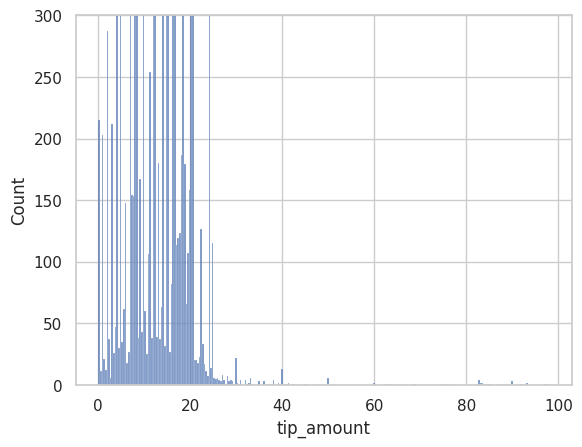

In [2]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
taxi.columns = taxi.columns.str.strip()
print(f"taxi shape. \nRows: \n{taxi.shape[0]}  columns: \n{taxi.shape[1]}")
print(f"\ntaxi head: \n{taxi.head()}")
print(f'\ntaxi info: \n{taxi.info()}')
print(f'\ntaxi description: \n{taxi.describe().T}')
print(f'\ntaxi missing values per column: \n{ taxi.isna().sum()}')

# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

#skew
mean_tip_am = taxi["tip_amount"].mean()  # stripping data is really important as it prevents errors here
median_tip_am= taxi["tip_amount"].median()
print(f"\nMean Tip amount:   {mean_tip_am:.2f}")
print(f"\nMedian Tip amount: {median_tip_am:.2f}")

#missing values
missing = (taxi.isnull().sum() / len(taxi) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
# Calcs percentage of data lost/missing in graph

#Full histogram
fig, ax = plt.subplots()
print(f"\nDistribution of the target tip_amount: \n{sns.histplot(taxi['tip_amount'], ax=ax)}")
ax.margins(x=0)
fig2, ax2 = plt.subplots()
print(f"\nDistribution of the target tip_amount (smaller values): \n{sns.histplot(taxi['tip_amount'], ax=ax2)}")
ax2.set_ylim(0,300)


**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** the data is slightly right skewed with a higher mean of 14.11 and higher median of 16.92 with zero missing values (identified from the earlier test).

The graph also shows the mean is around 14 dollars and there are some outliers on the far right of the graph however. This would need to be ignored/removed during preprocessing to prevent it from affecting the whole set of data when analysed

The zero figures in the graph is not high in comparison to the other bars and blends in well with the much lower figures. Because this value is meaningful it would not be altered in preprocessing as it represents those who did not play tips.



### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [3]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs;
#remove rows where trip_distance <= 0 or fare_amount <= 0;
taxi_rm = taxi[(taxi["trip_distance"]> 0) & (taxi["fare_amount"] >0)]
#   decide how to treat negative tip_amount values.
taxi_rm = taxi_rm[taxi_rm["tip_amount"] >= 0]#removing the negative values

miss_col=(taxi.isnull().sum()/len(taxi)*100).sort_values(ascending=False)
print(miss_col)

# TODO: Feature engineering — create at least ONE new, justified feature,
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

pd.get_dummies(taxi_rm,columns=["VendorID", "RatecodeID",
                             "payment_type", "store_and_fwd_flag"],
                              drop_first=True)


taxi_rm=pd.get_dummies(taxi_rm,columns=["VendorID", "RatecodeID",
                             "payment_type", "store_and_fwd_flag"],
                              drop_first=True)

taxi_rm["fare_per_passenger"] = (taxi_rm["fare_amount"]/taxi_rm["passenger_count"].replace(0, 1))

num_fields = ["passenger_count","trip_distance","fare_amount",
              "mta_tax","tolls_amount","improvement_surcharge",
              "tip_amount","fare_per_passenger"]

cat_fields = ["VendorID","RatecodeID","store_and_fwd_flag",
              "PULocationID","DOLocationID","payment_type"]

print(f"\nNumber of numerical values {len(num_fields)} n/Numberical values: {num_fields}")
print(f"Number of categorical values {len(cat_fields)} n/Categorical values: {cat_fields}")

# TODO: Scale the numeric features.
from sklearn.preprocessing import StandardScaler
sd_scaler = StandardScaler()

#   (fit on TRAIN only — see Part 1.3)


VendorID                 0.0
passenger_count          0.0
trip_distance            0.0
RatecodeID               0.0
store_and_fwd_flag       0.0
PULocationID             0.0
DOLocationID             0.0
payment_type             0.0
fare_amount              0.0
mta_tax                  0.0
tolls_amount             0.0
improvement_surcharge    0.0
tip_amount               0.0
dtype: float64

Number of numerical values 8 n/Numberical values: ['passenger_count', 'trip_distance', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'tip_amount', 'fare_per_passenger']
Number of categorical values 6 n/Categorical values: ['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type']


**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:**
I removed the invalid rows here simply due to uncertainty for their defintion. a negative tip could have meant anything from there being no tip to the driver owing the passenger money. It is more or less impossible for that to happen. For these uncertain reasons i just removed them completely


I added a fare_per_passenger feature that calculates the amount a passenger pays for their ride dependent on their cut of the bill. I believe this may have an inverse relationship to the target as less spend might increase the figure.

Using standard deviation here as the data set was large


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [4]:
# TODO: Separate features (X) and target y = tip_amount)
X = taxi_rm.drop(columns=["tip_amount"])
y_reg = taxi_rm["tip_amount"]

# TODO: Split into train / validation / test (a common choice is 60/20/20).
from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
X_temp, X_test, y_temp, y_test_reg = train_test_split(
    X,y_reg,test_size=0.2,random_state=RANDOM_STATE)

X_train, X_val, y_train_reg, y_val_reg = train_test_split(
    X_temp,y_temp,test_size=0.25,random_state=RANDOM_STATE)
#   Use random_state=RANDOM_STATE.

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
X_train_scaled = sd_scaler.fit_transform(X_train)
# we don't normalise and find s.d here cause we don't kknow the actual s.d and it would leak that value
X_train_scaled = sd_scaler.fit_transform(X_train)
X_val_scaled = sd_scaler.transform(X_val)
X_test_scaled = sd_scaler.transform(X_test)

median_le = y_reg.median()
y_clf = (y_reg > median_le).astype(int)

print(f"Features: {X.shape}")
print(f"Training data: {X_train.shape[0]} Test data: {X_test.shape[0]}")
print(f"Classification balance:\n{y_clf.value_counts()}")

Features: (41126, 13)
Training data: 24675 Test data: 8226
Classification balance:
tip_amount
0    32701
1     8425
Name: count, dtype: int64


**Student Reasoning — Splitting** *What ratio did you use? Why is a separate validation set useful in addition to a test set? Why must the scaler (and any imputation statistics) be fit on the training data only?*


> **Answer:** I used the common ratio where the training data is the most to expose the model to enough and to allow it to eventually predict accurately. This ensures it does not over exposed to certain values in its training and misunderstand those values outside of training and with real data.

The validation set just helps to double check the results from the test data and to check for final errors or overfitting.

The scalar is used only on the training data because it might have certain figures over represented in it. This can cause the model to focus on these specific fields instead of all if these values aren't made to not over shadow others.

### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

In [2]:
# TODO: Import, initialise, and train a regression model.
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)

#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
lin_reg_mod=LinearRegression()
tree_reg_mod=DecisionTreeRegressor(random_state=RANDOM_STATE)

# TODO: Predict on train, validation, and test sets.

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line)
models = { "Linear Regression": lin_reg_mod,"Decision Tree": tree_reg_mod}

lin_reg_mod.fit(X_train, y_train_reg)

lin_train_pred = lin_reg_mod.predict(X_train)
lin_val_pred = lin_reg_mod.predict(X_val)
lin_test_pred = lin_reg_mod.predict(X_test)

lin_results = {
    "Train RMSE": (mean_squared_error(y_train_reg, lin_train_pred)**0.5),
    "Val RMSE": (mean_squared_error(y_val_reg, lin_val_pred)**0.5),
    "Test RMSE": (mean_squared_error(y_test_reg, lin_test_pred)**0.5),

    "Train R2": r2_score(y_train_reg, lin_train_pred),
    "Val R2": r2_score(y_val_reg, lin_val_pred),
    "Test R2": r2_score(y_test_reg, lin_test_pred)
}

lin_RMSE = {
    "Train RMSE": (mean_squared_error(y_train_reg, lin_train_pred)**0.5),
    "Val RMSE": (mean_squared_error(y_val_reg, lin_val_pred)**0.5),
    "Test RMSE": (mean_squared_error(y_test_reg, lin_test_pred)**0.5)
}

lin_R2 = {
    "Train R2": r2_score(y_train_reg, lin_train_pred),
    "Val R2": r2_score(y_val_reg, lin_val_pred),
    "Test R2": r2_score(y_test_reg, lin_test_pred)
}

print(f"\nLinear Regression Results:")
print(pd.Series(lin_results).round(3))

tree_reg_mod.fit(X_train, y_train_reg)

tree_train_pred = tree_reg_mod.predict(X_train)
tree_val_pred = tree_reg_mod.predict(X_val)
tree_test_pred = tree_reg_mod.predict(X_test)

tree_results = {
    "Train RMSE": (mean_squared_error(y_train_reg, tree_train_pred)**0.5),
    "Val RMSE": (mean_squared_error(y_val_reg, tree_val_pred)**0.5),
    "Test RMSE": (mean_squared_error(y_test_reg, tree_test_pred)**0.5),

    "Train R2": r2_score(y_train_reg, tree_train_pred),
    "Val R2": r2_score(y_val_reg, tree_val_pred),
    "Test R2": r2_score(y_test_reg, tree_test_pred)
}

tree_RMSE = {
    "Train RMSE": (mean_squared_error(y_train_reg, tree_train_pred)**0.5),
    "Val RMSE": (mean_squared_error(y_val_reg, tree_val_pred)**0.5),
    "Test RMSE": (mean_squared_error(y_test_reg, tree_test_pred)**0.5)
}

tree_R2 = {
    "Train R2": r2_score(y_train_reg, tree_train_pred),
    "Val R2": r2_score(y_val_reg, tree_val_pred),
    "Test R2": r2_score(y_test_reg, tree_test_pred)
}

print(f"\nDecision Tree Results:")
print(pd.Series(tree_results).round(3))

reg_mods = {
    "Linear Regression": lin_reg_mod,
    "Decision Tree": tree_reg_mod
}

reg_df = pd.DataFrame({
    "Linear Regression": lin_results,
    "Decision Tree": tree_results
}).T

results_df = pd.DataFrame(results).T.sort_values("Test RMSE")
print(results_df)

best_reg_name = results_df["Test RMSE"].idxmin()
best_reg_model = models[best_reg_name]

y_pred_best_reg = best_reg_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test_reg, y_pred_best_reg, alpha=0.4, s=20, color="blue")
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    "r--",
    linewidth=1.5,
)
plt.xlabel("True Taxi Tip")
plt.ylabel("Predicted Tip amount")
plt.title(f"Predicted vs Actual - ({best_reg_name})")
plt.tight_layout()
plt.show()

print(f"Best model = {best_reg_name}")
print(
    f"RMSE: {reg_df.loc[best_reg_name, 'Test RMSE']:.3f} | R²: {reg_df.loc[best_reg_name, 'Test R2']:.3f}"
)

NameError: name 'RANDOM_STATE' is not defined

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:** [Double-click to edit]


---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

In [ ]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity=pd.read_csv(OBESITY_URL)
obesity.columns = obesity.columns.str.strip()

# TODO: Inspect shape, head, info, describe, and missing values.
print(f"\nshape: \n{obesity.shape}")
print(f"\nhead: \n{obesity.head()}")
print(f"\ninfo: \n{obesity.info()}")
print(f"\nhead: \n{obesity.describe().T}")
print(f"\ntaxi missing values per column: \n{ obesity.isna().sum()}")
# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?


print(obesity["NObeyesdad"].value_counts())
plt.figure(figsize=(10,5))
sns.countplot(data=obesity, y="NObeyesdad", order=obesity["NObeyesdad"].value_counts().index)
plt.title("Class Distribution of Obesity Levels\n")
plt.tight_layout()
plt.show()

mean_tip_am = taxi["tip_amount"].mean()  # stripping data is really important as it prevents errors here
median_tip_am= taxi["tip_amount"].median()
print(f"\nMean Tip amount:   {mean_tip_am:.2f}")
print(f"\nMedian Tip amount: {median_tip_am:.2f}")

#missing values
missing = (taxi.isnull().sum() / len(taxi) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
# Calcs percentage of data lost/missing in graph

#Full histogram
fig, ax = plt.subplots()
print(f"\nDistribution of the target tip_amount: \n{sns.histplot(taxi['tip_amount'], ax=ax)}")
ax.margins(x=0)
fig2, ax2 = plt.subplots()
print(f"\nDistribution of the target tip_amount (smaller values): \n{sns.histplot(taxi['tip_amount'], ax=ax2)}")
ax2.set_ylim(0,300)




**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:** theres 2111 records. Most of the data is categorical figures however the numeric categories are: Age, Height, Weight and numerical activity scores.
It's important the fields are balanced in classification otherwise the model would be bad at working on those classes that were smaller and imbalanced.



### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [ ]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
obesity_m = obesity.copy()


binary_map = {"yes": 1, "no": 0}
obesity_m["FAVC"] = obesity_m["FAVC"].map({"yes": 1, "no": 0})
obesity_m["SMOKE"] = obesity_m["SMOKE"].map({"yes": 1, "no": 0})
obesity_m["SCC"] = obesity_m["SCC"].map({"yes": 1, "no": 0})
obesity_m["family_history_with_overweight"] = obesity_m["family_history_with_overweight"].map({"yes": 1, "no": 0})
obesity_m["CAEC"] = obesity_m["CAEC"].map({"no":0, "Sometimes":1, "Frequently":2, "Always":3})
obesity_m["CALC"] = obesity_m["CALC"].map({"no":0, "Sometimes":1, "Frequently":2, "Always":3})

obesity_m= pd.get_dummies(obesity_m, columns=["Gender","MTRANS"], drop_first=True)

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
lbe = LabelEncoder()
obesity_m["NObeyesdad"] = lbe.fit_transform(obesity_m["NObeyesdad"])
# TODO: Scale the numeric features (fit on TRAIN only, in part 2.3).


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:** I encoded the binary values one by one for value because they only have 2 values to choose from.
I ordered the ordinal values "sequentially" because they increment exactly by one and are supposed to represent a sort of scale
MTRANS i used get.dummies to encode because it is still a categorical value but is not binary or sequential

No i did not engineer a feature however I think the BMI is ok to use as a feature because it doesn't cause leakage. The target is not directly used to expose itself during training.

I will use standard deviation for this data set due to its size

### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [ ]:
# TODO: Separate X (features) and y (encoded NObeyesdad).

X = obesity_m.drop(columns=["NObeyesdad"])
y = obesity_m["NObeyesdad"]

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

# TODO: Fit the scaler on the training set only, then transform train / val / test.

from sklearn.preprocessing import StandardScaler

sd_scaler = StandardScaler()
X_train_scaled = sd_scaler.fit_transform(X_train)
X_val_scaled = sd_scaler.transform(X_val)
X_test_scaled = sd_scaler.transform(X_test)

**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:**
Here I used the same split ratio as in the first example 60/20/20 for the same reason as before. It gives the model enough room to leaen. But the amount has been controlled to allow enough testing and validation checks to be preformed after
Stratify helps maintain an even ratio of fields when split. This ratio usually mimicks one in reality.
Without stratifying first you risk over exposing the model to an environment that doesn't display the real life statistics



### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

In [ ]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

# TODO: Predict on train, validation, and test.

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.show()

**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:** [Double-click to edit]


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


In [ ]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.


In [ ]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?


**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:** [Double-click to edit]


---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:** [Double-click to edit]


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
